In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install ultralytics==8.3.235


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.8 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
print("Ultralytics imported successfully!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics imported successfully!


In [6]:
from google.colab import files
print("Upload your Roboflow dataset ZIP now.")
uploaded = files.upload()


Upload your Roboflow dataset ZIP now.


Saving Beach Garbage.v2i.yolov8.zip to Beach Garbage.v2i.yolov8.zip


In [7]:
import zipfile, os

dataset_zip = list(uploaded.keys())[0]
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extracted dataset to /content/dataset")


Extracted dataset to /content/dataset


In [8]:
!ls dataset


data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [9]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    name="marine_waste_model"
)


New https://pypi.org/project/ultralytics/8.3.236 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=marine_waste_model, nbs=64, nms=False, opset=Non

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e60d788aae0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [10]:
!find /content -name "best.pt"


/content/runs/detect/marine_waste_model/weights/best.pt


In [11]:
from google.colab import files
uploaded_img = files.upload()


Saving CD_14444_jpg.rf.195d49f0e723172775fe61018b99176e.jpg to CD_14444_jpg.rf.195d49f0e723172775fe61018b99176e.jpg


In [12]:
!ls


'Beach Garbage.v2i.yolov8.zip'			        runs
 CD_14444_jpg.rf.195d49f0e723172775fe61018b99176e.jpg   sample_data
 dataset					        yolo11n.pt
 drive						        yolov8s.pt


In [17]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/marine_waste_model/weights/best.pt")
model.predict(source="CD_14444_jpg.rf.195d49f0e723172775fe61018b99176e.jpg", save=True)



image 1/1 /content/CD_14444_jpg.rf.195d49f0e723172775fe61018b99176e.jpg: 640x640 3 Sampahs, 16.2ms
Speed: 1.9ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Sampah'}
 obb: None
 orig_img: array([[[ 62,  63,  73],
         [ 83,  84,  94],
         [112, 113, 123],
         ...,
         [132, 135, 140],
         [131, 134, 139],
         [131, 134, 139]],
 
        [[ 82,  83,  93],
         [100, 101, 111],
         [123, 124, 134],
         ...,
         [134, 137, 142],
         [133, 136, 141],
         [133, 136, 141]],
 
        [[111, 112, 122],
         [123, 124, 134],
         [137, 138, 148],
         ...,
         [136, 139, 144],
         [135, 138, 143],
         [135, 138, 143]],
 
        ...,
 
        [[137, 139, 140],
         [136, 138, 139],
         [135, 137, 138],
         ...,
         [138, 141, 145],
         [139, 142, 146],
         [139, 142, 146]],
 
        [[136, 138, 139],
         [136, 138, 139],
         [135, 137, 138],
         ...,
         [139, 142

In [18]:
from google.colab import files
files.download("/content/runs/detect/marine_waste_model/weights/best.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
files.download("/content/runs/detect/predict/CD_14444_jpg.rf.195d49f0e723172775fe61018b99176e.jpg")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
print("Upload your Roboflow dataset ZIP now.")
uploaded = files.upload()


Upload your Roboflow dataset ZIP now.


Saving Beach Garbage.v2i.yolov8.zip to Beach Garbage.v2i.yolov8 (1).zip


In [ ]:
import zipfile, os

dataset_zip = list(uploaded.keys())[0]   # gets the uploaded zip filename
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extracted dataset to /content/dataset")


Extracted dataset to /content/dataset


In [ ]:
!ls dataset


data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!pip install ultralytics
from ultralytics import YOLO


STEP 2:

In [20]:
from ultralytics import YOLO
print("Ultralytics imported successfully.")


Ultralytics imported successfully.


In [21]:
model = YOLO("yolov8s.pt")


In [22]:
model.train(
    data="dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    name="marine_waste_model"
)


New https://pypi.org/project/ultralytics/8.3.236 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=marine_waste_model2, nbs=64, nms=False, opset=No

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e6263ea9be0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

STEP 3:

In [23]:
!find /content -name "best.pt"


/content/runs/detect/marine_waste_model2/weights/best.pt
/content/runs/detect/marine_waste_model/weights/best.pt


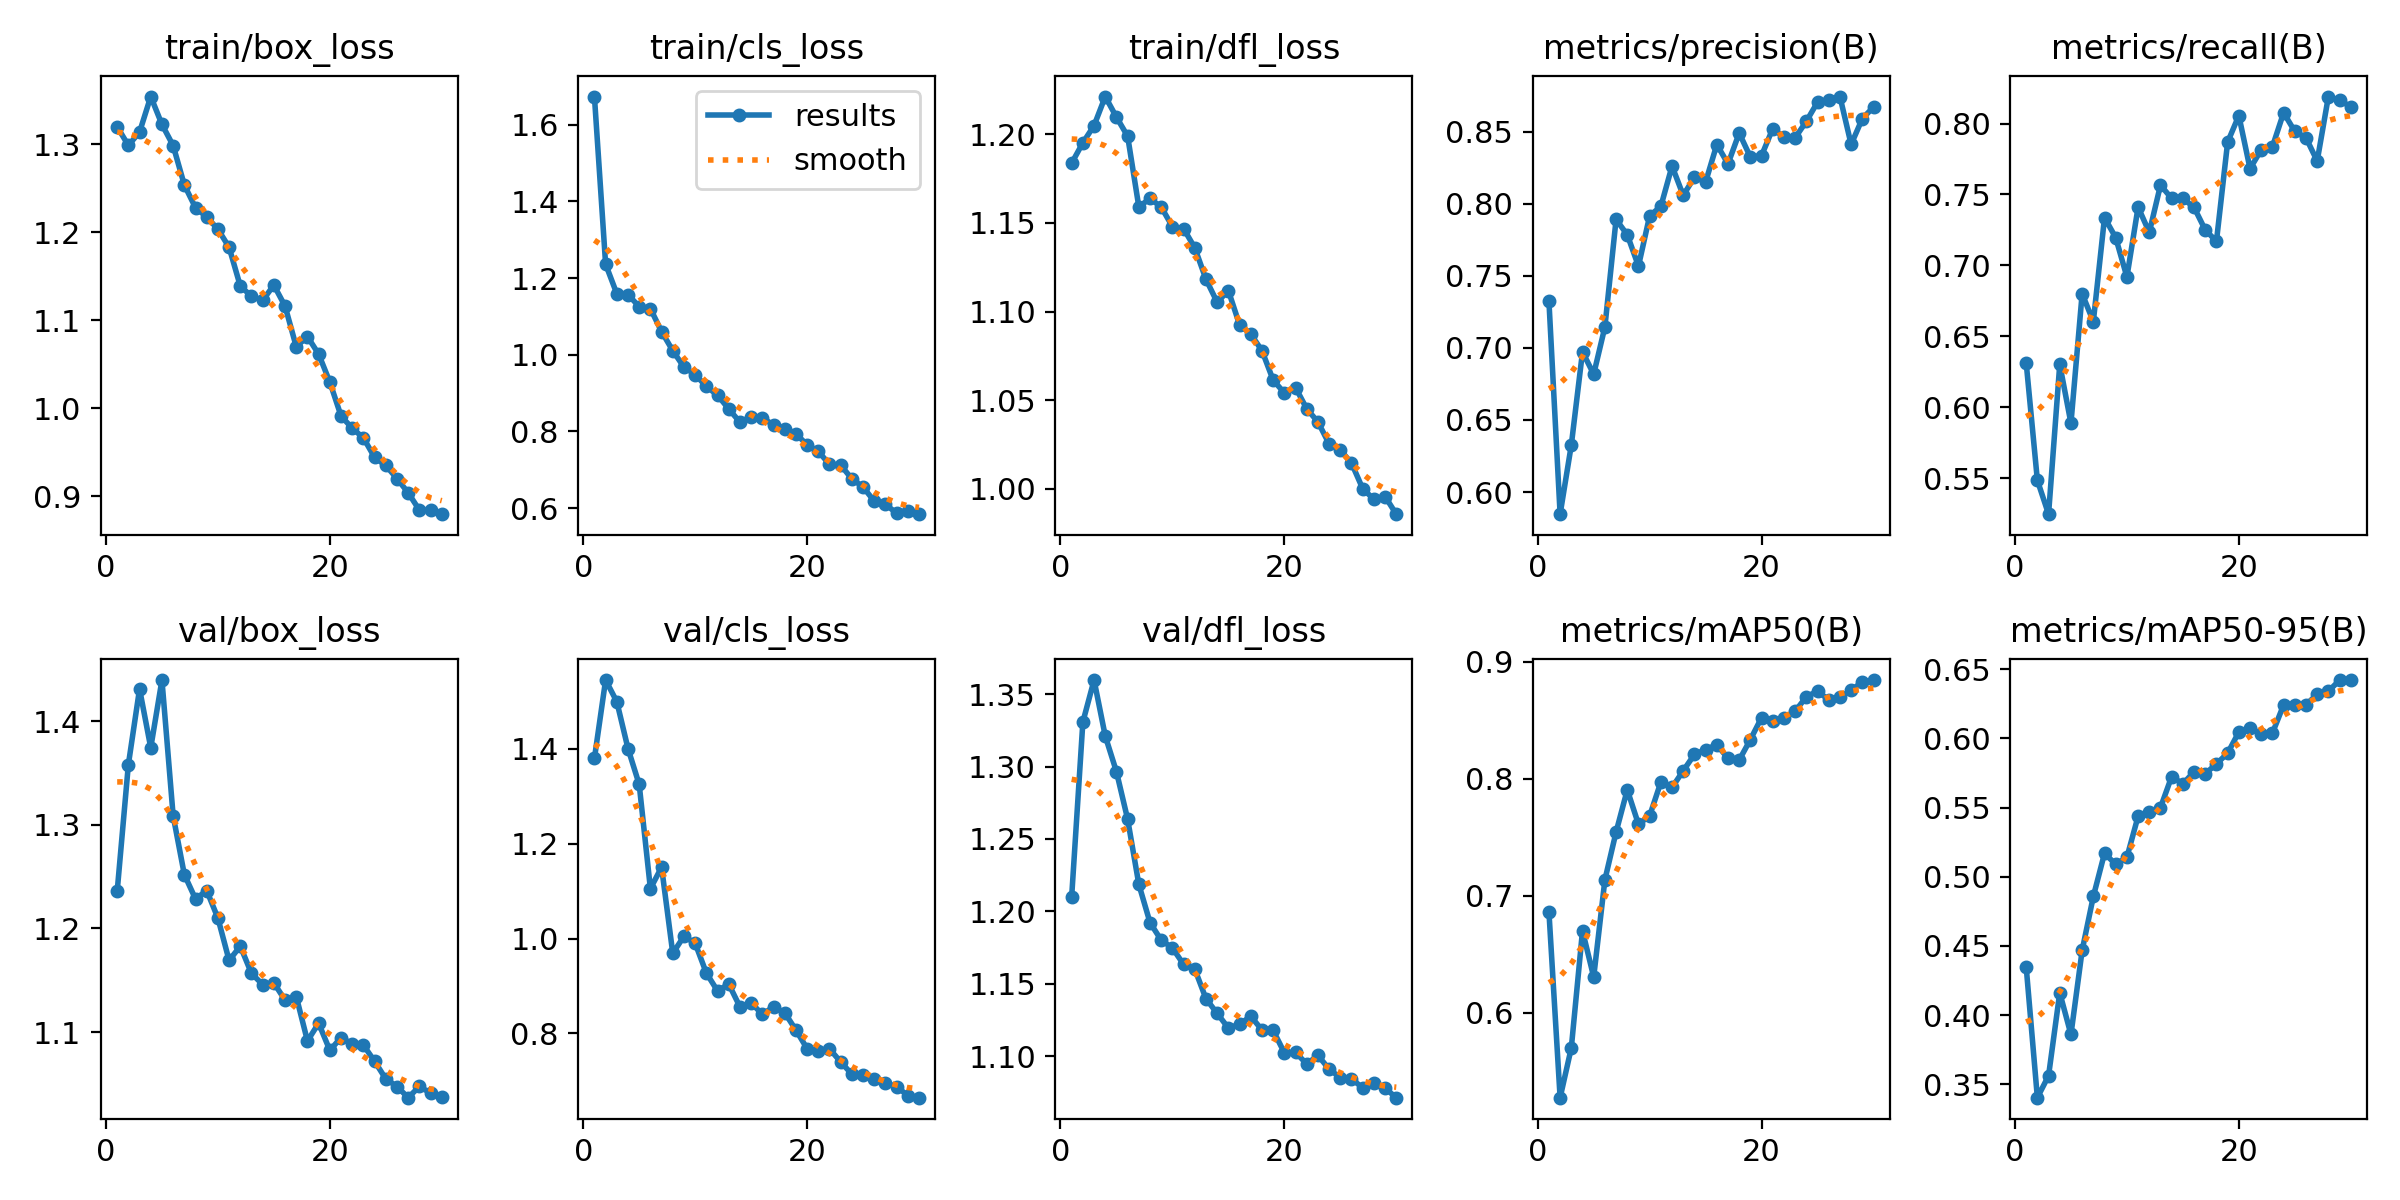

In [24]:
from IPython.display import Image

Image("/content/runs/detect/marine_waste_model/results.png")


In [25]:
print(model.metrics)


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e6263ea9be0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

STEP 4 :

In [26]:
from ultralytics import YOLO
model = YOLO("/content/runs/detect/marine_waste_model/weights/best.pt")


In [27]:
model.train(
    data="dataset/data.yaml",
    epochs=15,         # fine-tuning epochs
    imgsz=640,
    batch=8,
    name="marine_waste_finetuned",
)


New https://pypi.org/project/ultralytics/8.3.236 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/marine_waste_model/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=mar

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e623cd8a840>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [28]:
!find /content -name "best.pt"


/content/runs/detect/marine_waste_model2/weights/best.pt
/content/runs/detect/marine_waste_finetuned/weights/best.pt
/content/runs/detect/marine_waste_model/weights/best.pt


STEP 5 (testing phase)

In [29]:
model = YOLO("/content/runs/detect/marine_waste_finetuned/weights/best.pt")


In [30]:
from google.colab import files
uploaded_img = files.upload()


Saving CD_12002_jpg.rf.0719f758277bd8941027a5a3f8d039e5.jpg to CD_12002_jpg.rf.0719f758277bd8941027a5a3f8d039e5.jpg


In [31]:
!ls


'Beach Garbage.v2i.yolov8.zip'			        dataset   sample_data
 CD_12002_jpg.rf.0719f758277bd8941027a5a3f8d039e5.jpg   drive	  yolo11n.pt
 CD_14444_jpg.rf.195d49f0e723172775fe61018b99176e.jpg   runs	  yolov8s.pt


In [32]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/marine_waste_model/weights/best.pt")
model.predict(source="CD_12002_jpg.rf.0719f758277bd8941027a5a3f8d039e5.jpg", save=True)


image 1/1 /content/CD_12002_jpg.rf.0719f758277bd8941027a5a3f8d039e5.jpg: 640x640 3 Sampahs, 16.2ms
Speed: 1.9ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Sampah'}
 obb: None
 orig_img: array([[[149, 160, 168],
         [148, 159, 167],
         [147, 158, 166],
         ...,
         [159, 164, 167],
         [159, 164, 167],
         [158, 163, 166]],
 
        [[149, 160, 168],
         [148, 159, 167],
         [147, 158, 166],
         ...,
         [160, 165, 168],
         [159, 164, 167],
         [159, 164, 167]],
 
        [[149, 160, 168],
         [148, 159, 167],
         [148, 159, 167],
         ...,
         [160, 165, 168],
         [160, 165, 168],
         [160, 165, 168]],
 
        ...,
 
        [[116, 127, 135],
         [116, 127, 135],
         [116, 127, 135],
         ...,
         [146, 155, 165],
         [146, 155, 165],
         [146, 155, 165]],
 
        [[117, 128, 136],
         [116, 127, 135],
         [116, 127, 135],
         ...,
         [146, 155

In [36]:
from google.colab import files
files.download("/content/runs/detect/predict2/CD_12002_jpg.rf.0719f758277bd8941027a5a3f8d039e5.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>